# Introduction

In this notebook, we are going to practice building a 2D Convolutional Neural Network to process the MNIST dataset. This is a classic problem, the goal is to build a tool which can accurately classify images of hand written digits as 0, 1, 2, etc. Some common applications for this kind of program include reading text off bank checks, reading hand written zip codes for the post office.


# Imports

We start by importing the packages and modules we will be needing for this project.

In [1]:
# Load standard numerical and plotting packages
import numpy as np
import matplotlib.pyplot as plt

# Load some machine learning packages
from sklearn.model_selection import train_test_split

# scikit-learn performance metric utilities
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# import our neural network building tools
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# Set plotting preferences
import matplotlib
%matplotlib inline
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 16}
matplotlib.rc('font', **font)

## Download the Dataset

The MNIST dataset contains thousands of grayscale images of handwritten digits.

In [3]:
from torchvision import datasets, transforms

transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    '../data', train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    '../data', train=False, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256)

## Data shape

MNIST is a grey scale digits dataset. Here's the general shape of our dataset. 

In [4]:
example_images = train_dataset.data[:16]
example_labels = train_dataset.targets[:16]

print(f"Shape of X: {example_images.shape}")
print(f"Shape of y: {example_labels.shape}")

Shape of X: torch.Size([16, 28, 28])
Shape of y: torch.Size([16])


## Visualize Some Example Images
Let's see how the images look. This function shows a random example along with it's corresponding label.

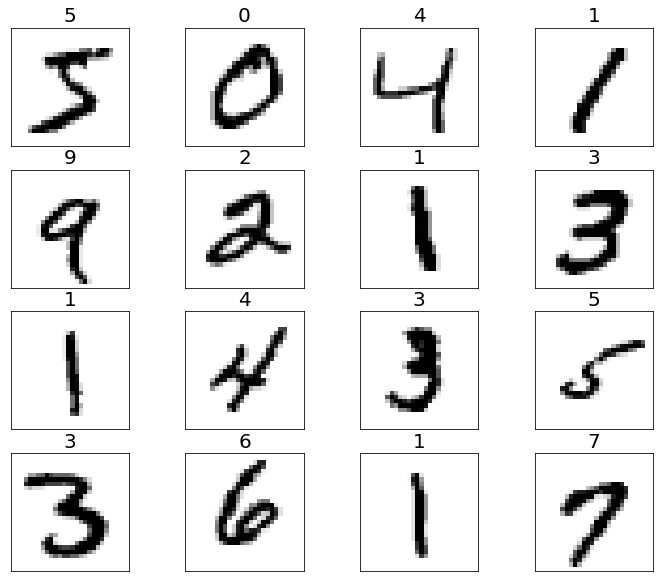

In [5]:
# Setup the number of images to examine
n_rows = 4
n_cols = 4
img_inds = np.random.randint(0, len(example_labels), size=n_rows*n_cols)
# Initialize a set of subplots to populate and an image counter
fig, ax_arr = plt.subplots(n_rows, n_cols, figsize=(12, 10))
i_img = 0
img_ind =0

# Loop over the axes rows and columns
for ax_row in range(n_rows):
    for ax_col in range(n_cols):
        # Grab the axes instance for this row/column
        this_ax = ax_arr[ax_row, ax_col]

        # Show the image and update the title with the label
        this_ax.imshow(example_images[img_ind], cmap='gray_r')
        this_ax.set_title(example_labels[img_ind].item(), fontdict={'size': 20})
        this_ax.set_xticks([])
        this_ax.set_yticks([])

        # Increment the image index
        img_ind += 1

## Data augmentation

In computer vision, it isn't uncommon to use `data augmentation` to help improve model generalization by artificially generating more samples for our data. We must always be careful when dealing with artificially generated data, but there are a few scenarios where you can safely generate data without fearing that the generated data is unrepresentative of the underlying data distribution.

Consider an image of a "hand." If you flip the image, it is still a "hand". That means flipping the image is a `label invariant` transformation--the label of the image doesn't change even after we applied the transformation. However, say we were trying to predict whether this is a "left hand" or a "right hand." This is now no longer a label invariant transformation. 

Even if a transformation is label invariant, it may introduce samples that won't be seen at inference time--which could potentially introduce bias. Always be mindful of any synthetic data.

The following code cell implements a data augmentation pipeline. One or more of the following transformations are inappropriate. Remove them accordingly. 


In [6]:
example_images.shape

torch.Size([16, 28, 28])

In [7]:
# Feel free to experiment with different augmentation pipelines!
# At least one transformation shouldnt be here, however

transformations = torch.nn.Sequential(
    transforms.RandomResizedCrop(28, scale=(0.6, 1.0), antialias=None), #Randomly crops and resizes the image
    transforms.RandomRotation(15), #Randomly rotates the image by an amount between -15 and 15 degrees
    # transforms.RandomHorizontalFlip(p=0.2), #Randomly flips the image vertically with probability 0.2
)

Here's what these transformations look like for reference. Hint: these are all supposed to be '5', but some of them doesn't look like a '5' do they? What transformation is causing that?

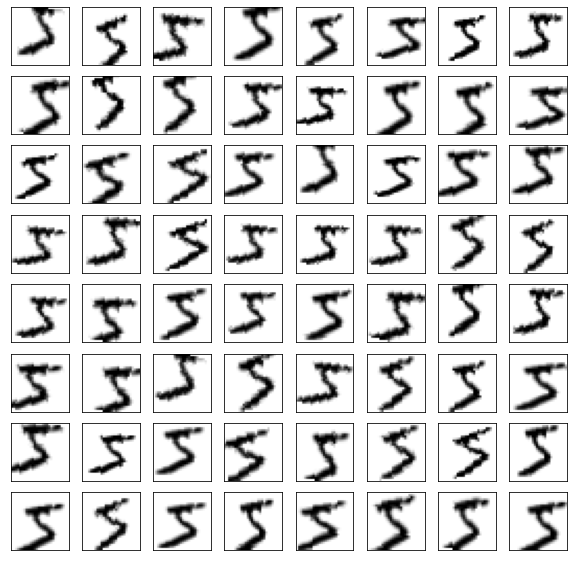

In [8]:
fig, ax = plt.subplots(8,8, figsize=(10, 10))
for i in range(8):
    for j in range (8):
        ax[i][j].imshow(transformations(example_images[0].unsqueeze(0))[0], cmap='gray_r')
        ax[i][j].set_xticks([])
        ax[i][j].set_yticks([])
plt.show()

><details>
>  <summary>Answer</summary>
>  
>  We shouldn't be randomly flipping images since '5' becomes a '2' when flipped, so this isn't a label invariant transformation
>  
>  
></details>

## Build a CNN Model
To practice building a *specific* CNN architecture, your task is to build the same architecture shown in this diagram.

![CNN Architecture](https://github.com/BeaverWorksMedlytics2020/Data_Public/raw/master/Images/Week3/CNN-example-block-diagram.jpg)

In [9]:
vanilla_model = nn.Sequential( 
    # TODO: implement the model from the above diagram
    nn.Conv2d(1, 32, 5),
    nn.ReLU(),
    nn.MaxPool2d((2, 2), stride=2),

    nn.Conv2d(32, 64, 5, stride=1),
    nn.ReLU(),
    nn.MaxPool2d((2, 2), stride=2),

    nn.Conv2d(64, 64, 2, stride=1),
    nn.ReLU(),
    nn.MaxPool2d((2, 2), stride=1),

    nn.Flatten(),
    nn.Linear(256,10)
)

import copy
augmentation_model = copy.deepcopy(vanilla_model) # for later

In [10]:
def train_and_score(model, augment_data=True):
    epochs = 5

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        for i, data in enumerate(train_loader):
            # Train loop
            model.train()
            inputs, labels = data

            # Apply the transformations
            if augment_data:
                inputs = transformations(inputs)

            # Pytorch keeps track of gradients across loops, so we need to zero it for each batch
            # We need to manually zero the gradient--reset it--every batch
            optimizer.zero_grad()
    
            outputs = model(inputs) # Get the model's output
            loss = criterion(outputs, labels) # Compute the loss
            preds = torch.argmax(outputs,dim=1)

            # For monitoring
            tr_loss = loss.item()
            tr_acc = torch.sum(preds==labels)/len(labels)

            loss.backward() # Backpropagate to compute gradient
            optimizer.step() # Update the parameters, according to chosen optimizer algorithm

        print(f'Train loss: {tr_loss:.3f}, Train Accurayc: {tr_acc:.3f}')

    model.eval()
    with torch.no_grad():
        ts_loss = []
        ts_acc = []
        for i, data in enumerate(test_loader):
            inputs, labels = data
    
            outputs = model(inputs) # Get the model's output
            loss = criterion(outputs, labels) # Compute the loss
            preds = torch.argmax(outputs,dim=1)

            # For monitoring
            ts_loss.append(loss.item())
            ts_acc.append(torch.sum(preds==labels)/len(labels))

        ts_loss = torch.tensor(ts_loss).mean()
        ts_acc = torch.tensor(ts_acc).mean()

    print(f'Test loss: {ts_loss:.3f}, Test Accurayc: {ts_acc:.3f}')

In [11]:
# This is training the model without using any data augmentation
train_and_score(vanilla_model, augment_data=False)

Train loss: 0.283, Train Accurayc: 0.979
Train loss: 0.249, Train Accurayc: 0.990
Train loss: 0.226, Train Accurayc: 0.990
Train loss: 0.216, Train Accurayc: 0.990
Train loss: 0.204, Train Accurayc: 0.990
Test loss: 0.033, Test Accurayc: 0.989


In [12]:
# This is training the model with data augmentation
train_and_score(augmentation_model, augment_data=True)

Train loss: 0.247, Train Accurayc: 0.979
Train loss: 0.429, Train Accurayc: 0.865
Train loss: 0.282, Train Accurayc: 0.958
Train loss: 0.183, Train Accurayc: 0.979
Train loss: 0.151, Train Accurayc: 0.990
Test loss: 0.059, Test Accurayc: 0.980


Notice how using the augmentation pipeline makes it much more difficult for our model to fit to the problem during training, however, the test performance seems to be roughly even. 

This suggests that the augmentation pipeline is making the problem more 'challenging' for our model, but that it is still generalizing well, which is good. 

### Interpretability

An important part of building models is being able to explain what our models are doing. This isn't always possible in deep learning, but luckily there are many tools that can help us. 

One way of doing so is using `saliency maps` which shows parts of the input that affects the model prediction the most

In [13]:
def saliency(img, model):
    #we don't need gradients w.r.t. weights for a trained model
    for param in model.parameters():
        param.requires_grad = False
    
    #set model in eval mode
    model.eval()
    #transoform input PIL image to torch.Tensor and normalize
    input = img.float()
    input.unsqueeze_(0)

    #we want to calculate gradient of higest score w.r.t. input
    #so set requires_grad to True for input 
    input.requires_grad = True
    #forward pass to calculate predictions
    preds = model(input)
    score, indices = torch.max(preds, 1)
    #backward pass to get gradients of score predicted class w.r.t. input image
    score.backward()
    #get max along channel axis
    slc, _ = torch.max(torch.abs(input.grad[0]), dim=0)
    #normalize to [0..1]
    slc = (slc - slc.min())/(slc.max()-slc.min())

    #apply inverse transform on image
    with torch.no_grad():
        input_img = (input*0.3081) - 0.1307
    
    #plot image and its saleincy map
    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.imshow(input_img.detach().numpy()[0][0], cmap='gray_r')
    plt.xticks([])
    plt.yticks([])
    plt.subplot(1, 2, 2)
    plt.imshow(slc.numpy(), cmap=plt.cm.hot)
    plt.xticks([])
    plt.yticks([])
    plt.show()

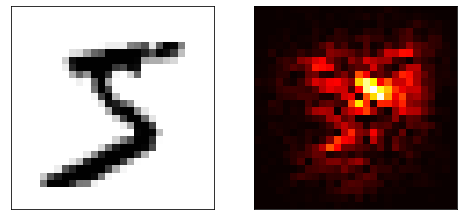

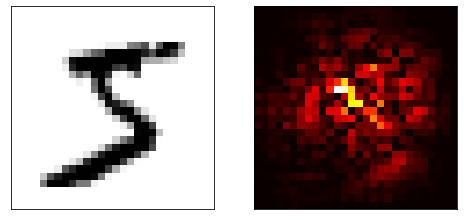

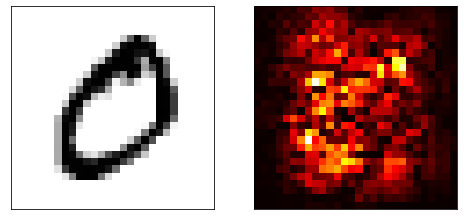

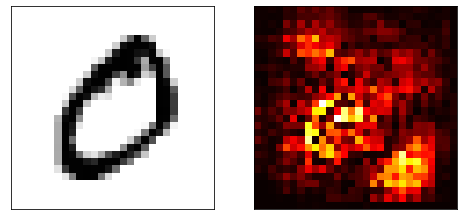

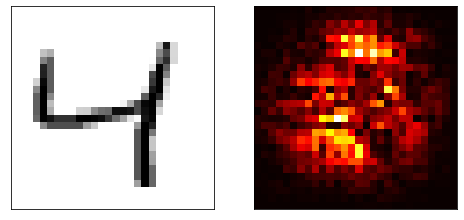

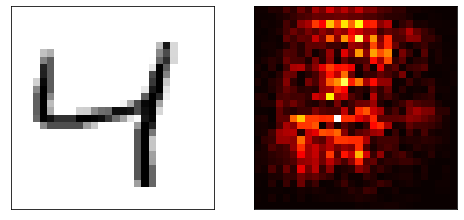

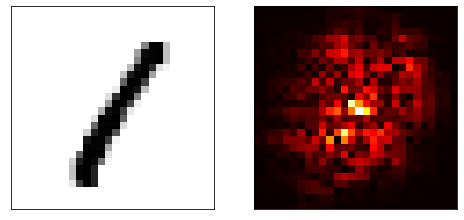

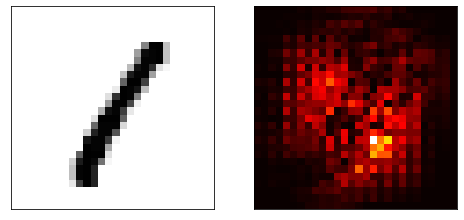

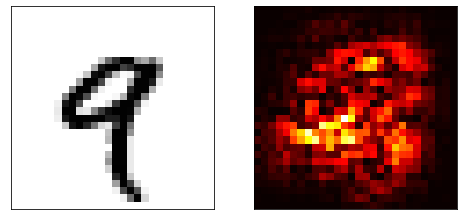

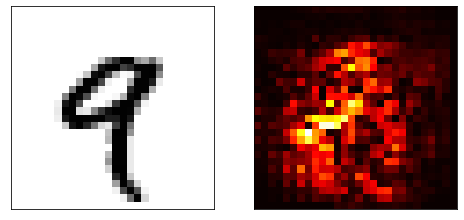

In [14]:
for i in range(5):
    saliency(example_images[i].unsqueeze(0), vanilla_model)
    saliency(example_images[i].unsqueeze(0), augmentation_model)

Notice how the augmentation pipeline causes the model to pay attention to much more of the overall image than any single part. For instance: the corners of the images are almost always completely dark for the vanilla model, however, the augmented model actually pays attention to them. 


The fact that our augmented model is looking at the image more holistically while still maintaining good testing accuracy suggests it is generalizing better.